# Oregon Data Center Heat Vulnerability Status

This notebook summarizes Month 2 progress using a systems-dependency approach for data-center vulnerability.

## Scope for this run
- Heat-only (flood and wildfire are deferred and represented as placeholders in tables)
- LOCA2 model/member: ACCESS-CM2 r1i1p1f1
- Time windows: historical 1950-1979 and SSP585 2070-2099
- Heat indices: CDD, Tmax threshold-days (>35C), heatwave events (>=3 consecutive days >35C)

## Key assumptions
- Power linkage uses a conservative proxy in this version: facility -> nearest candidate substations (top-k within service radius) -> nearby generation plants within proxy radius
- Generation redundancy is counted at plant level (unit rows collapsed) to reduce overcounting of independent sources
- One-hop transmission expansion is disabled by default in this version
- **Important interpretation:** substation cap (top-k) is used only for generation-linkage computation; reported substation redundancy columns are uncapped
- Water source type field is set to `unknown` until source-type enrichment is added
- Heat values are sampled at generation-plant locations and aggregated to facility-level means

In [6]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import rasterio

ROOT = Path('/home/server/pi/homes/queenl/projects/climate-risk-dc')
OUT = ROOT / 'outputs' / 'month2_heat'

RASTERS = {
    'CDD HIST': OUT / 'rasters' / 'cdd_historical_1950_1979.tif',
    'CDD FUT': OUT / 'rasters' / 'cdd_ssp585_2070_2099.tif',
    'TMAX DAYS HIST': OUT / 'rasters' / 'tmax_threshold_days_historical_1950_1979.tif',
    'TMAX DAYS FUT': OUT / 'rasters' / 'tmax_threshold_days_ssp585_2070_2099.tif',
    'HEATWAVE HIST': OUT / 'rasters' / 'heatwave_events_historical_1950_1979.tif',
    'HEATWAVE FUT': OUT / 'rasters' / 'heatwave_events_ssp585_2070_2099.tif',
}

SUMMARY_CSV = OUT / 'dependency_table_facility_summary.csv'
EDGES_CSV = OUT / 'dependency_table_generation_edges.csv'
DC_CSV = ROOT / 'data' / 'data_centers_im3_pnnl' / 'im3_open_source_data_center_atlas_v2026.02.09.csv'
WBD_GDB = ROOT / 'data' / 'watershed_boundaries' / 'WBD_National_GDB.gdb'

In [7]:
def load_oregon_boundary() -> gpd.GeoDataFrame:
    wbd = gpd.read_file(WBD_GDB, layer='WBDHU8')
    if wbd.crs is None:
        wbd = wbd.set_crs('EPSG:4326')
    wbd = wbd.to_crs('EPSG:4326')
    if 'states' in wbd.columns:
        wbd = wbd[wbd['states'].fillna('').str.contains('OR')]
    return gpd.GeoDataFrame(geometry=[wbd.union_all()], crs='EPSG:4326')


def load_oregon_data_centers() -> gpd.GeoDataFrame:
    dc = pd.read_csv(DC_CSV)
    dc = dc[dc['state_abb'] == 'OR'].copy()
    return gpd.GeoDataFrame(dc, geometry=gpd.points_from_xy(dc['lon'], dc['lat']), crs='EPSG:4326')


boundary = load_oregon_boundary()
dc = load_oregon_data_centers()
summary = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()
edges = pd.read_csv(EDGES_CSV) if EDGES_CSV.exists() else pd.DataFrame()

print('Data centers:', len(dc))
print('Summary rows:', len(summary))
print('Edge rows:', len(edges))

Data centers: 109
Summary rows: 109
Edge rows: 8633


## Heat Index Maps with Data Centers Overlay

/tmp/ipykernel_3623250/3136231391.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(float)


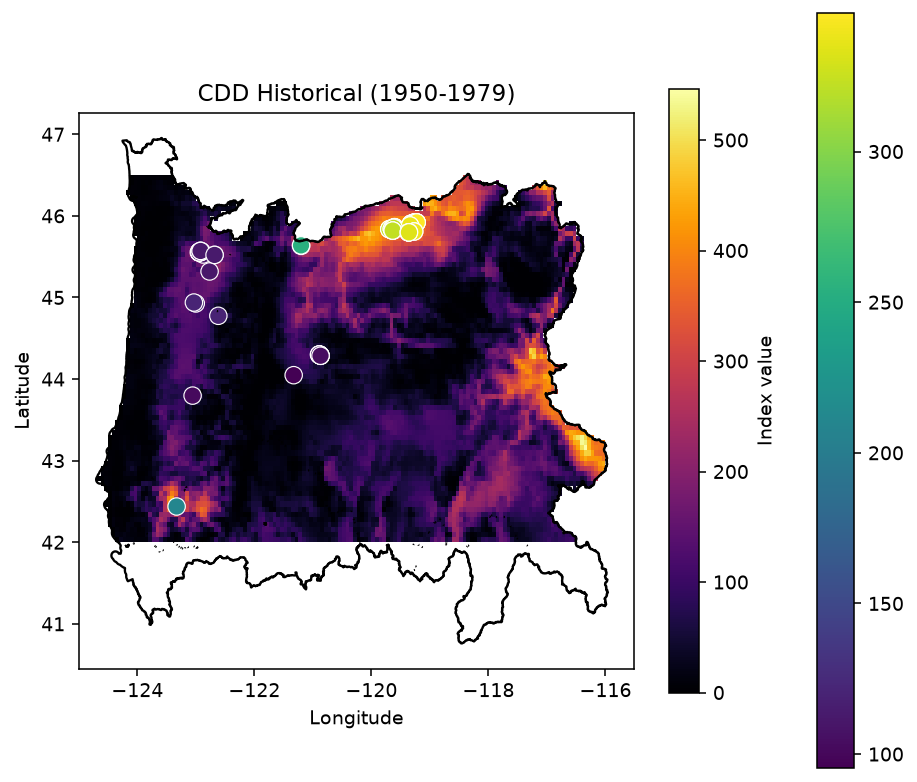

/tmp/ipykernel_3623250/3136231391.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(float)


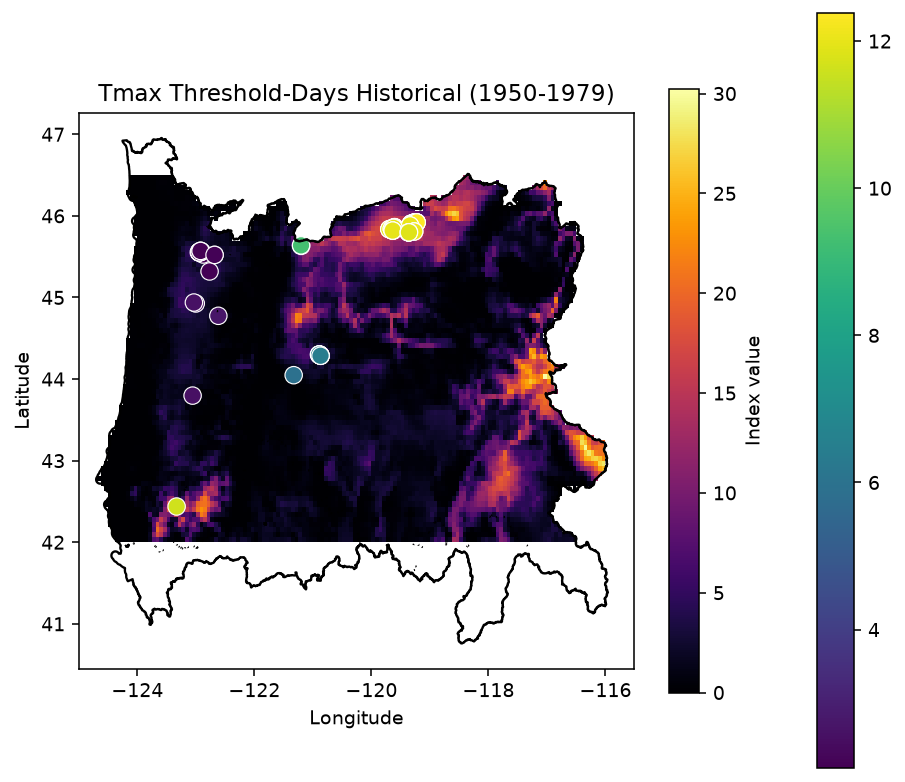

/tmp/ipykernel_3623250/3136231391.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(1).astype(float)


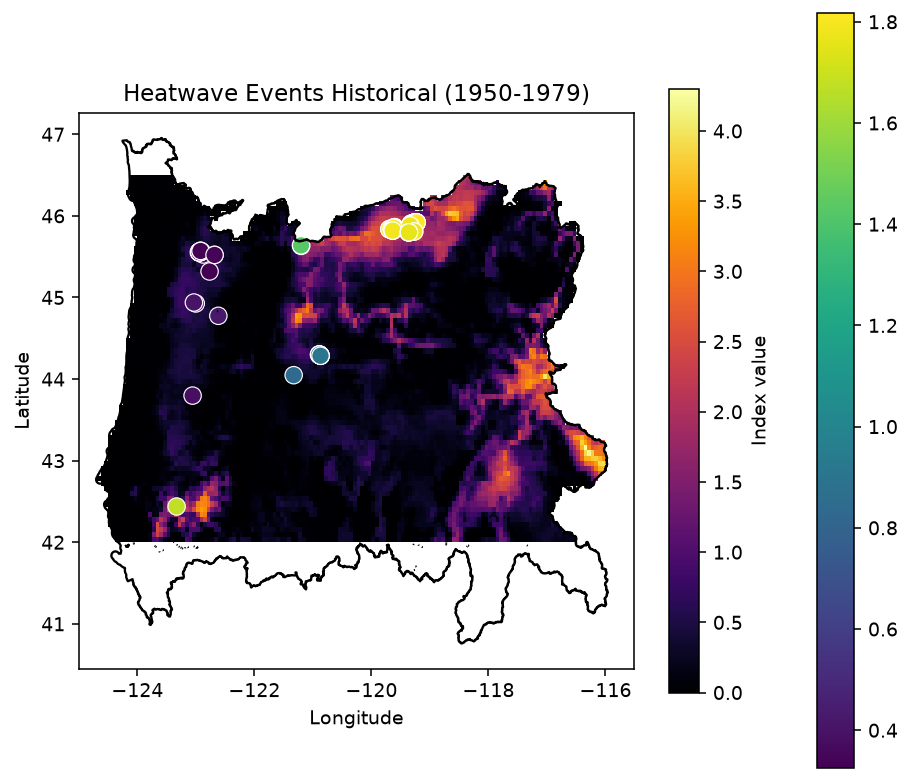

In [3]:
def plot_raster_with_dc(raster_path: Path, title: str, value_col: str | None = None):
    if not raster_path.exists():
        print(f'Missing raster: {raster_path.name}')
        return

    fig, ax = plt.subplots(figsize=(8, 7), dpi=140)
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype(float)
        arr[arr <= -1e30] = np.nan
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    im = ax.imshow(arr, extent=extent, origin='upper', cmap='inferno')
    boundary.boundary.plot(ax=ax, color='black', linewidth=1.2)

    if value_col and not summary.empty and value_col in summary.columns:
        merged = dc.merge(summary[['facility_id', value_col]], left_on='id', right_on='facility_id', how='left')
        pts = gpd.GeoDataFrame(merged, geometry='geometry', crs='EPSG:4326')
        pts.plot(ax=ax, column=value_col, cmap='viridis', markersize=80, edgecolor='white', linewidth=0.6, legend=True)
    else:
        dc.plot(ax=ax, color='cyan', edgecolor='black', markersize=70, linewidth=0.6)

    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Index value')
    plt.show()


plot_raster_with_dc(
    RASTERS['CDD HIST'],
    'CDD Historical (1950-1979)',
    value_col='cdd_historical_1950_1979_gen_mean'
)
plot_raster_with_dc(
    RASTERS['TMAX DAYS HIST'],
    'Tmax Threshold-Days Historical (1950-1979)',
    value_col='tmax_threshold_days_historical_1950_1979_gen_mean'
)
plot_raster_with_dc(
    RASTERS['HEATWAVE HIST'],
    'Heatwave Events Historical (1950-1979)',
    value_col='heatwave_events_historical_1950_1979_gen_mean'
)

## Redundancy Summary

,facility_name,substations_within_service_radius_count,connected_substations_count,generation_plant_count,generation_unit_count_proxy,generation_fuel_type_count,water_source_count,fiber_provider_count_gte_1gbps
0,Meta Prineville Datacenter,3,3,25,38,4,0,1
1,Apple Prineville Datacenter,3,3,25,38,4,1,0
2,NTT RagingWire Data Center,3,3,114,211,11,1,2
3,Google Data Center The Dalles Oregon,3,3,49,129,6,1,1
4,NaN,3,3,25,38,4,1,1
...,...,...,...,...,...,...,...,...
104,QTS North HIL3 North Building,3,3,114,211,11,0,1
105,QTS North HIL3 South Building,3,3,114,211,11,0,1
106,FCR,3,3,21,33,4,1,3
107,The Pittock Internet Exchange,3,3,109,188,9,1,6


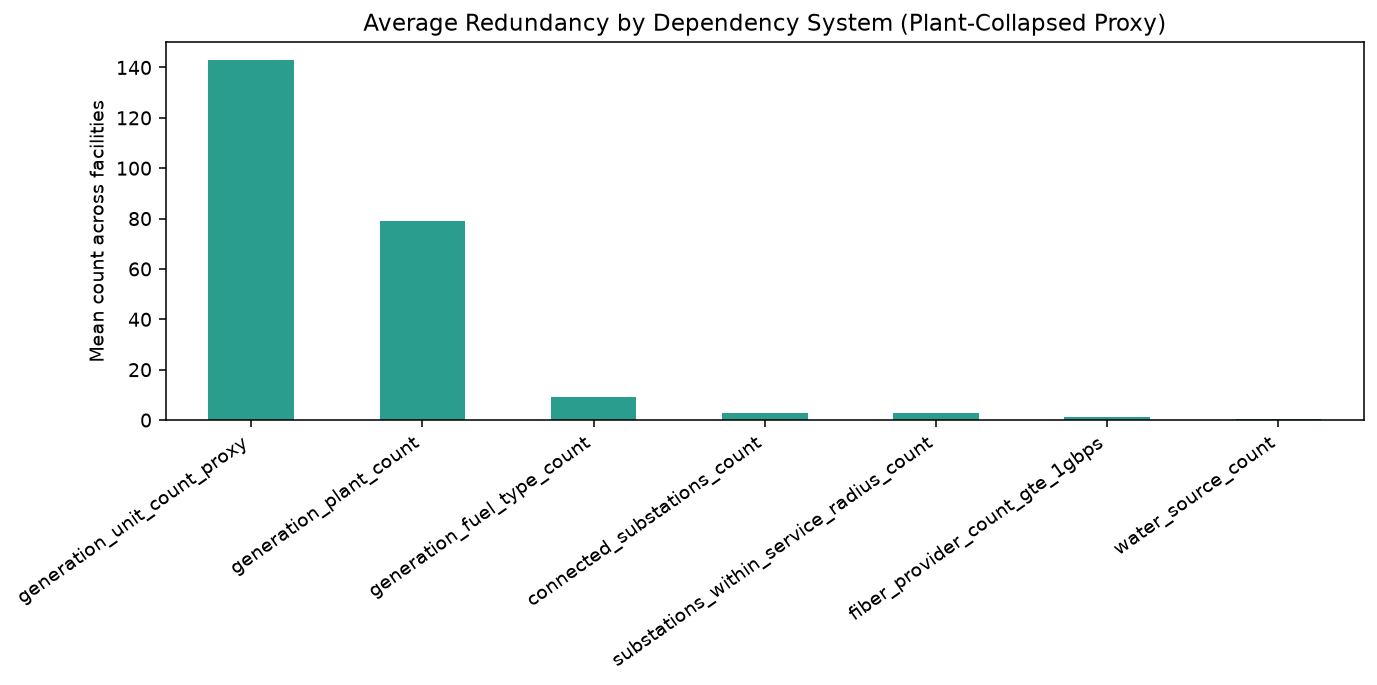

In [ ]:
if summary.empty:
    print('Dependency summary table not found yet.')
else:
    gen_col = 'generation_plant_count' if 'generation_plant_count' in summary.columns else 'generation_source_count'
    cols = [
        'substations_within_service_radius_count',
        'substations_used_for_generation_count' if 'substations_used_for_generation_count' in summary.columns else 'connected_substations_count',
        'connected_substations_count',
        'connected_substations_used_for_generation_count' if 'connected_substations_used_for_generation_count' in summary.columns else 'connected_substations_count',
        gen_col,
        'generation_unit_count_proxy' if 'generation_unit_count_proxy' in summary.columns else 'generation_fuel_type_count',
        'generation_fuel_type_count',
        'water_source_count',
        'fiber_provider_count_gte_1gbps',
    ]
    display_cols = ['facility_name'] + [c for c in cols if c in summary.columns]
    display(summary[display_cols])

    fig, ax = plt.subplots(figsize=(11, 5), dpi=140)
    summary[[c for c in cols if c in summary.columns]].mean().sort_values(ascending=False).plot(kind='bar', ax=ax, color='#2a9d8f')
    ax.set_ylabel('Mean count across facilities')
    ax.set_title('Average Redundancy by Dependency System (Uncapped Reporting + Capped Linkage)')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Example Dependency Diagrams

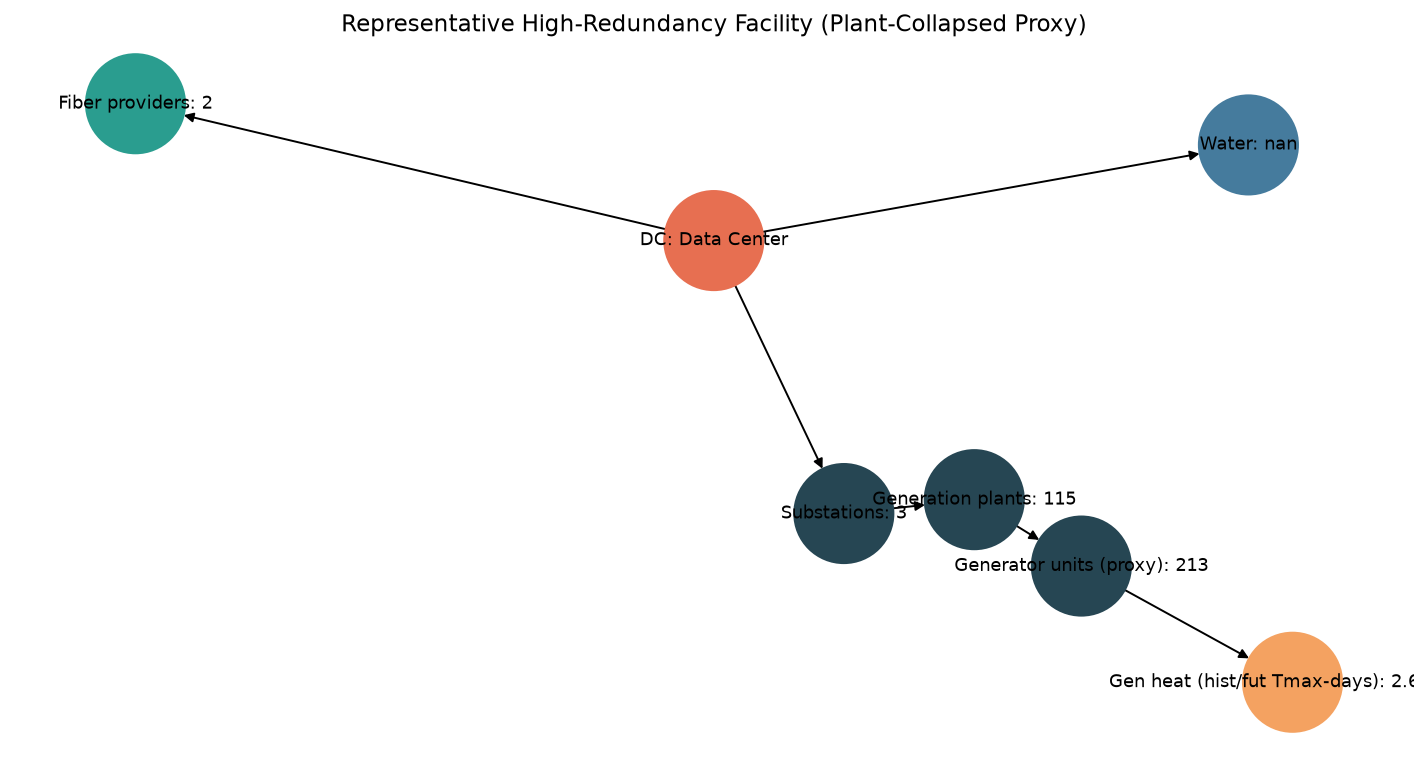

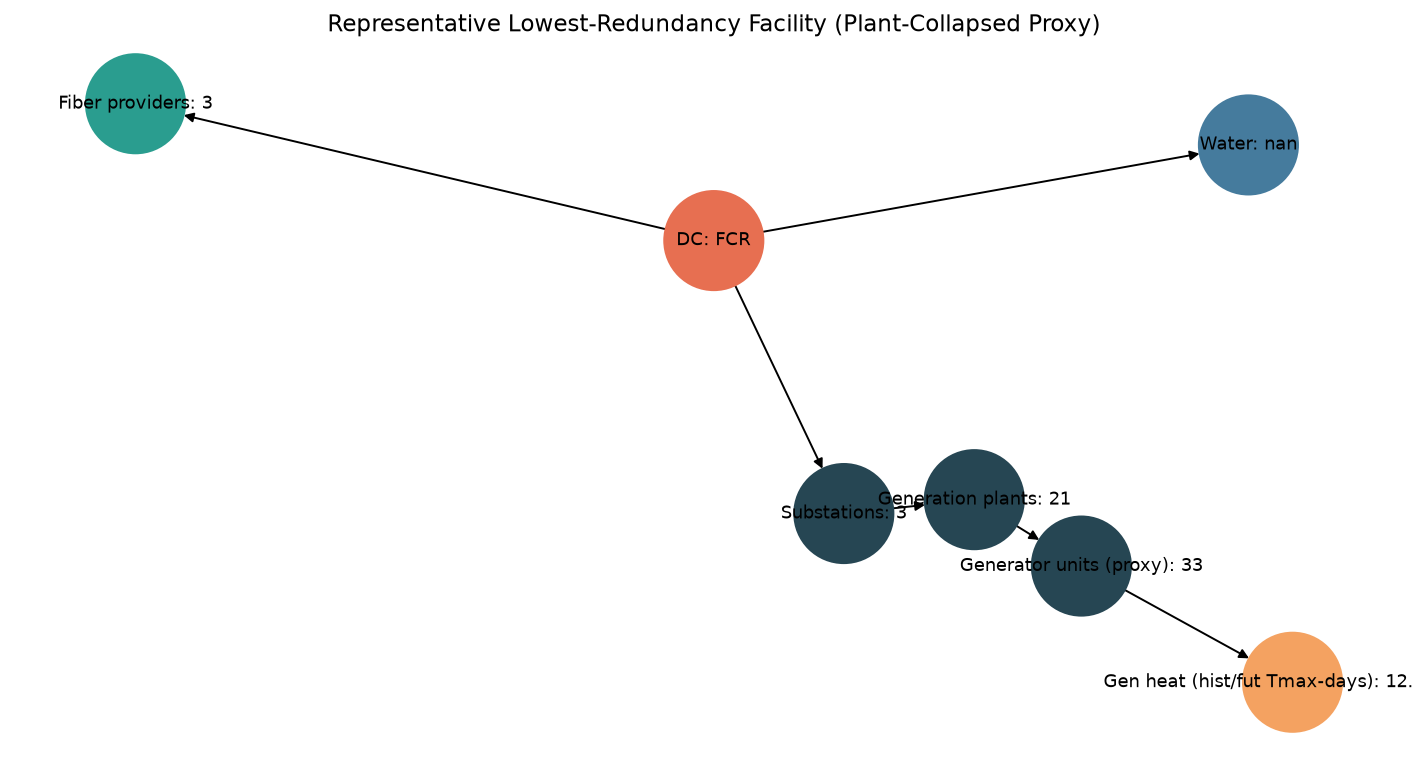

In [ ]:
def build_facility_graph(facility_id: str) -> nx.DiGraph:
    g = nx.DiGraph()
    row = summary[summary['facility_id'].astype(str) == str(facility_id)].iloc[0]
    g.add_node(f"DC: {row['facility_name']}", kind='dc')

    gen_col = 'generation_plant_count' if 'generation_plant_count' in row.index else 'generation_source_count'
    g.add_node(f"Substations (uncapped): {int(row['substations_within_service_radius_count'])}", kind='power')
    if 'substations_used_for_generation_count' in row.index:
        g.add_node(f"Substations used for gen-linkage: {int(row['substations_used_for_generation_count'])}", kind='power')
    g.add_node(f"Generation plants: {int(row[gen_col])}", kind='power')
    if 'generation_unit_count_proxy' in row.index:
        g.add_node(f"Generator units (proxy): {int(row['generation_unit_count_proxy'])}", kind='power')
    g.add_node(f"Water: {row['water_system_name']}", kind='water')
    g.add_node(f"Fiber providers: {int(row['fiber_provider_count_gte_1gbps'])}", kind='fiber')

    heat_label = (
        f"Gen heat (hist/fut Tmax-days): {row['tmax_threshold_days_historical_1950_1979_gen_mean']:.1f} / "
        f"{row['tmax_threshold_days_ssp585_2070_2099_gen_mean']:.1f}"
    )
    g.add_node(heat_label, kind='heat')

    dc_node = f"DC: {row['facility_name']}"
    uncapped_sub = f"Substations (uncapped): {int(row['substations_within_service_radius_count'])}"
    g.add_edge(dc_node, uncapped_sub)
    if 'substations_used_for_generation_count' in row.index:
        used_sub = f"Substations used for gen-linkage: {int(row['substations_used_for_generation_count'])}"
        g.add_edge(uncapped_sub, used_sub)
        g.add_edge(used_sub, f"Generation plants: {int(row[gen_col])}")
    else:
        g.add_edge(uncapped_sub, f"Generation plants: {int(row[gen_col])}")
    if 'generation_unit_count_proxy' in row.index:
        g.add_edge(f"Generation plants: {int(row[gen_col])}", f"Generator units (proxy): {int(row['generation_unit_count_proxy'])}")
        g.add_edge(f"Generator units (proxy): {int(row['generation_unit_count_proxy'])}", heat_label)
    else:
        g.add_edge(f"Generation plants: {int(row[gen_col])}", heat_label)
    g.add_edge(dc_node, f"Water: {row['water_system_name']}")
    g.add_edge(dc_node, f"Fiber providers: {int(row['fiber_provider_count_gte_1gbps'])}")
    return g


def plot_graph(g: nx.DiGraph, title: str):
    color_map = {'dc': '#e76f51', 'power': '#264653', 'water': '#457b9d', 'fiber': '#2a9d8f', 'heat': '#f4a261'}
    node_colors = [color_map.get(g.nodes[n].get('kind', ''), '#999999') for n in g.nodes]
    pos = nx.spring_layout(g, seed=42)
    plt.figure(figsize=(11, 6), dpi=140)
    nx.draw(g, pos, with_labels=True, node_color=node_colors, node_size=2800, font_size=8, arrows=True)
    plt.title(title)
    plt.axis('off')
    plt.show()


if summary.empty or len(summary) < 2:
    print('Need dependency summary with at least two facilities to draw representative graphs.')
else:
    gen_col = 'generation_plant_count' if 'generation_plant_count' in summary.columns else 'generation_source_count'
    high = summary.sort_values(gen_col, ascending=False).iloc[0]['facility_id']
    low = summary.sort_values(gen_col, ascending=True).iloc[0]['facility_id']

    plot_graph(build_facility_graph(str(high)), 'Representative High-Redundancy Facility (Uncapped Substation Reporting)')
    plot_graph(build_facility_graph(str(low)), 'Representative Lowest-Redundancy Facility (Uncapped Substation Reporting)')

In [13]:
summary.sort_values(gen_col, ascending=False).iloc[0]

facility_id                                                                                  369728508
facility_name                                                                              Data Center
facility_lon                                                                               -122.875504
facility_lat                                                                                 45.526684
nearest_substation_id                                                                            59016
nearest_substation_distance_m                                                              1852.389096
substations_within_service_radius_count                                                              3
connected_substations_count                                                                          3
generation_source_count                                                                            115
generation_plant_count                                                   

## Caveats and Deferred Items
- Flood and wildfire metrics are placeholders only in this run.
- Power-chain linkage remains a proxy and should not be interpreted as contractual dispatch topology.
- Generation counts are plant-collapsed in this version to reduce unit-level overcounting, but still reflect proxy-based candidate exposure neighborhoods.
- Substation reporting uses uncapped redundancy counts; capped substation counts are shown separately as computational linkage inputs for generation buffers.
- Water source-type remains `unknown` pending source-type mapping enrichment.